# ADSC 3040 Project 
## Investment Portfolio Optimization
Date: December 4, 2025

Mint Thai - T00762325\
Cynthia Urrutia - T00735328

# Table of Contents

1. [Introduction](#Introduction)
   - [Exploratory Data Analysis](#Exploratory-Data-Analysis)
2. [Research Questions and Objectives](#Research-Questions-and-Objectives)
3. [Results](#Results)
   - [Portfolio Optimization](#Portfolio-Optimization)
   - [Sensitivity Analysis](#Sensitivity-analysis)
4. [Conclusion](#Conclusion)
5. [Appendix](#Appendix)
   - [Methodologies & Formulas](#Methodologies--Formulas)

In [14]:
import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])


In [15]:
# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)


# Introduction

In finance, high-return assets often entail high volatility or move closely together, making it challenging to decide which stocks to include in a portfolio that balances return, risk, and diversification. This project addresses that problem by developing a model that optimizes expected returns while managing risk, subject to constraints around risk tolerance, diversification, and correlation.

Using historical S&P 500 pricing data from November 2020 to November 2025, we compute weighted returns, volatility, and correlation measures that feed into the optimization model. The final portfolio solutions are generated through linear optimization and evaluated across three investor profiles: Aggressive, Balanced, and Conservative. Each is defined by different constraint levels.

The analysis includes data processing, exploratory data analysis, the construction of the optimization model, and sensitivity testing to understand how constraint choices affect portfolio outcomes.

## Exploratory Data Analysis

Based on pricing data scraped from Yahoo Finance over the last 5 years, the whole dataset contains approximately half a million rows covering all 503 S&P 500 companies across 11 industries. To simplify the analysis and reduce computational demand, a representative subset of the index is selected by choosing the three highest-weighted companies from each sector. This results in 33 decision variables, collectively representing 49.9% of the overall index.

The subset consists of five years of daily information, including price data (open, close, high, low), trading volume, ticker symbol, security name, sector, and index weight.

In [16]:
sp500_subset.head()

,Date,Close,High,Low,Open,Volume,Symbol,Security,Sector,Weight
0,2020-11-23,84.081802,84.559074,83.168406,83.884313,7541500,ABBV,AbbVie,Health Care,0.007
1,2020-11-24,85.546516,86.254193,84.410945,84.657805,9322200,ABBV,AbbVie,Health Care,0.007
2,2020-11-25,85.744026,85.957977,85.077496,85.431334,6368100,ABBV,AbbVie,Health Care,0.007
3,2020-11-27,86.311798,87.060621,85.826302,86.385860,4418800,ABBV,AbbVie,Health Care,0.007
4,2020-11-30,86.056725,86.747940,85.291446,86.501080,20726500,ABBV,AbbVie,Health Care,0.007


In [ ]:
# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max:", sp500_subset["Date"].max())
print("\nNumber of symbols in price subset:", sp500_subset["Symbol"].nunique())
print("\nMissing values:")
print(sp500_subset.isna().sum())

In [ ]:
# Weights and Sectors Data

print("Weight data shape:", sectors_wgts.shape)
print("\nColumns in weight data:", sectors_wgts.columns)
print("Number of sectors in weight dataset:", sectors_wgts["Sector"].nunique())
print("\nMissing values:")
print(sectors_wgts.isna().sum())

In [ ]:
print(sp500_subset.head())
print(sp500_subset.isna().sum())

missing = sp500_subset[sp500_subset["Weight"].isna()]["Symbol"].unique()
print("Symbols missing weights:", missing)

In [25]:
# Total sum of weights from S&P 500 subset

unique_securities = (
    sp500_subset[["Symbol", "Security", "Sector", "Weight"]]
    .drop_duplicates("Symbol")
    .sort_values("Weight", ascending=False)
)

sum_weights = unique_securities["Weight"].sum()

Total sum of weights in S&P 500 subset: 49.96%


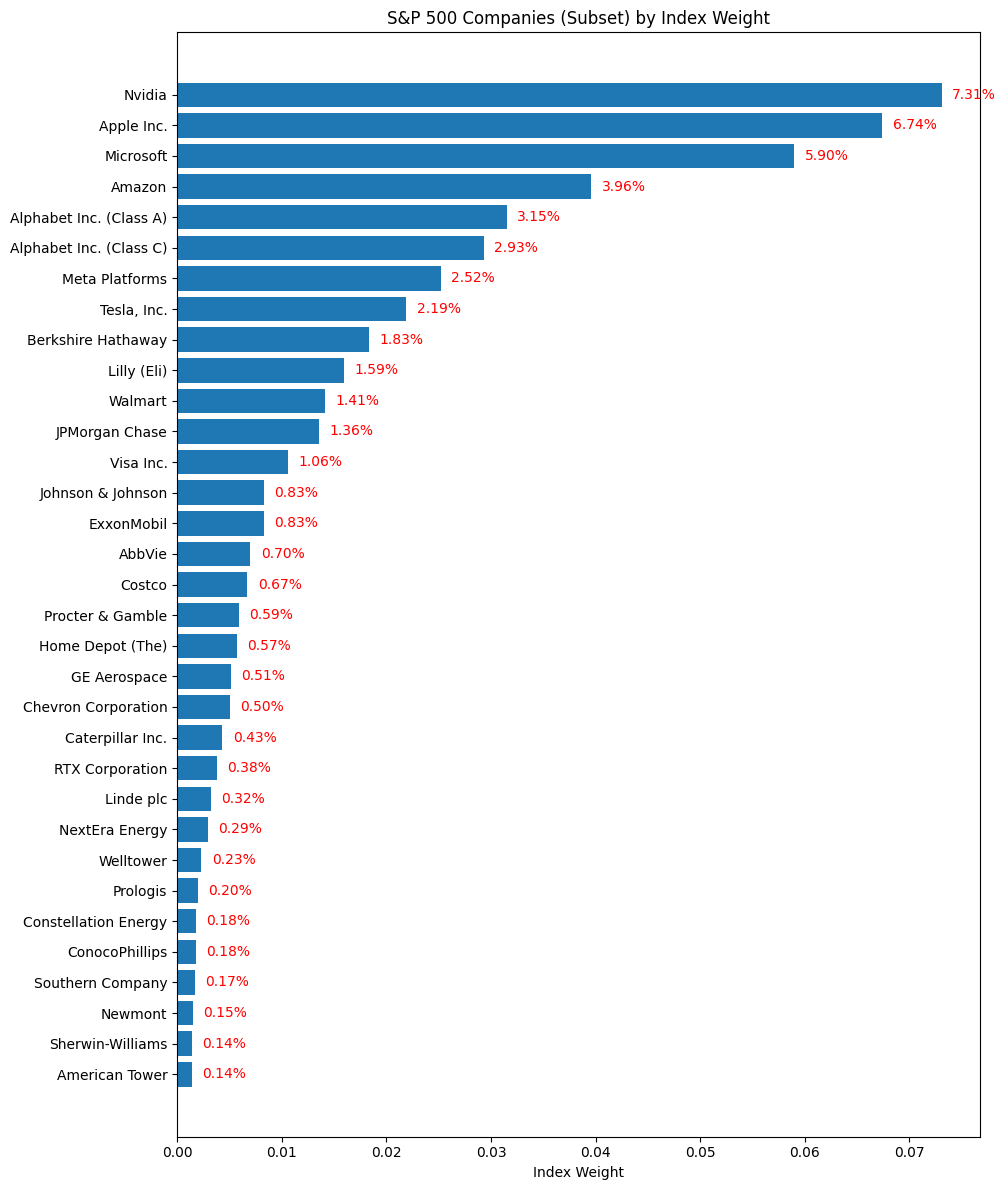

In [27]:
# Plot all S&P 500 Subset companies by weight with % labels

print(f"Total sum of weights in S&P 500 subset: {sum_weights*100:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
bars = plt.barh(
    unique_securities["Security"],
    unique_securities["Weight"]
)
plt.gca().invert_yaxis()
plt.title("S&P 500 Companies (Subset) by Index Weight")
plt.xlabel("Index Weight")
plt.tight_layout()

# Add % labels in red at the end of each bar
for bar, weight in zip(bars, unique_securities["Weight"]):
    plt.text(
        bar.get_width() + 0.001,  # Slightly after the end of the bar
        bar.get_y() + bar.get_height() / 2,
        f"{weight*100:.2f}%",
        va='center',
        ha='left',
        color='red',
        fontsize=10
    )

plt.show()




In [22]:
# Calculate daily returns and log returns
import numpy as np

sp500_subset2 = sp500_subset.sort_values(["Symbol", "Date"]).copy()

sp500_subset2["Return"] = (
    sp500_subset2.groupby("Symbol")["Close"]
    .transform(lambda x: x.pct_change())
)

sp500_subset2["LogReturn"] = np.log1p(sp500_subset2["Return"])

Annual returns and standard deviations (used as measures of performance and risk) are computed using weighted metrics based on the following distribution across the five-year window:

| 2020 | 2021 |  2022 |  2023 |  2024 |  2025 |
|------|------|-------|-------|-------|-------|
|  5%  |  5%  |  10%  |  20%  |  30%  |  30%  |

A summary of these calculations is shown in the table below. The weighting scheme accounts for the unusual market conditions during the pandemic years (2020–2021) and places greater emphasis on recent years, when the AI-driven rally materially influenced market dynamics.

In [29]:
# Weighted Summary Statistics

import numpy as np
import pandas as pd

# Assign Year + Weights
sp500_subset2["Year"] = sp500_subset2["Date"].dt.year
year_weights = {2020:0.05, 2021:0.05, 2022:0.10, 2023:0.20, 2024:0.30, 2025:0.30}
sp500_subset2["YearWeight"] = sp500_subset2["Year"].map(year_weights)

# ---- Weighted Functions ----

def weighted_mean(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    return np.average(v, weights=w)

def weighted_sd(values, weights):
    mask = values.notna()
    v = values[mask]
    w = weights[mask]
    mean_w = np.average(v, weights=w)
    var_w = np.average((v - mean_w)**2, weights=w)
    return np.sqrt(var_w)

# ---- Grouped weighted calculations ----

weighted_summary = (
    sp500_subset2
        .groupby("Symbol")
        .apply(
            lambda g: pd.Series({
                "W_Daily_Return": weighted_mean(g["Return"], g["YearWeight"]),
                "W_Daily_LogReturn": weighted_mean(g["LogReturn"], g["YearWeight"]),
                "W_SD_Return": weighted_sd(g["Return"], g["YearWeight"]),
                "W_SD_LogReturn": weighted_sd(g["LogReturn"], g["YearWeight"])
            }),
            include_groups=False
        )
        .reset_index()
)

# ---- Annualizations ----

weighted_summary["W_Annual_LogReturn"] = weighted_summary["W_Daily_LogReturn"] * 252
weighted_summary["W_Annual_Return"] = np.exp(weighted_summary["W_Annual_LogReturn"]) - 1

weighted_summary["W_Annual_SD"] = weighted_summary["W_SD_Return"] * np.sqrt(252)
weighted_summary["W_Annual_LogSD"] = weighted_summary["W_SD_LogReturn"] * np.sqrt(252)

# ---- Summary ----

weighted_summary = weighted_summary[[
    "Symbol",
    "W_Daily_Return",
    "W_Annual_Return",
    "W_SD_Return",
    "W_Annual_SD",
]]

weighted_summary.head()

,Symbol,W_Daily_Return,W_Annual_Return,W_SD_Return,W_Annual_SD
0,AAPL,0.000893,0.205531,0.017461,0.277187
1,ABBV,0.000871,0.211540,0.014721,0.233689
2,AMT,-0.000058,-0.047029,0.016336,0.259325
3,AMZN,0.000927,0.191257,0.021554,0.342156
4,BRK-B,0.000693,0.173847,0.010636,0.168835


The box plots of annual return and annual standard deviation show clear differences in performance and risk across sectors. Higher-return sectors generally exhibit higher volatility, while defensive sectors tend to offer lower returns with more stable behavior.

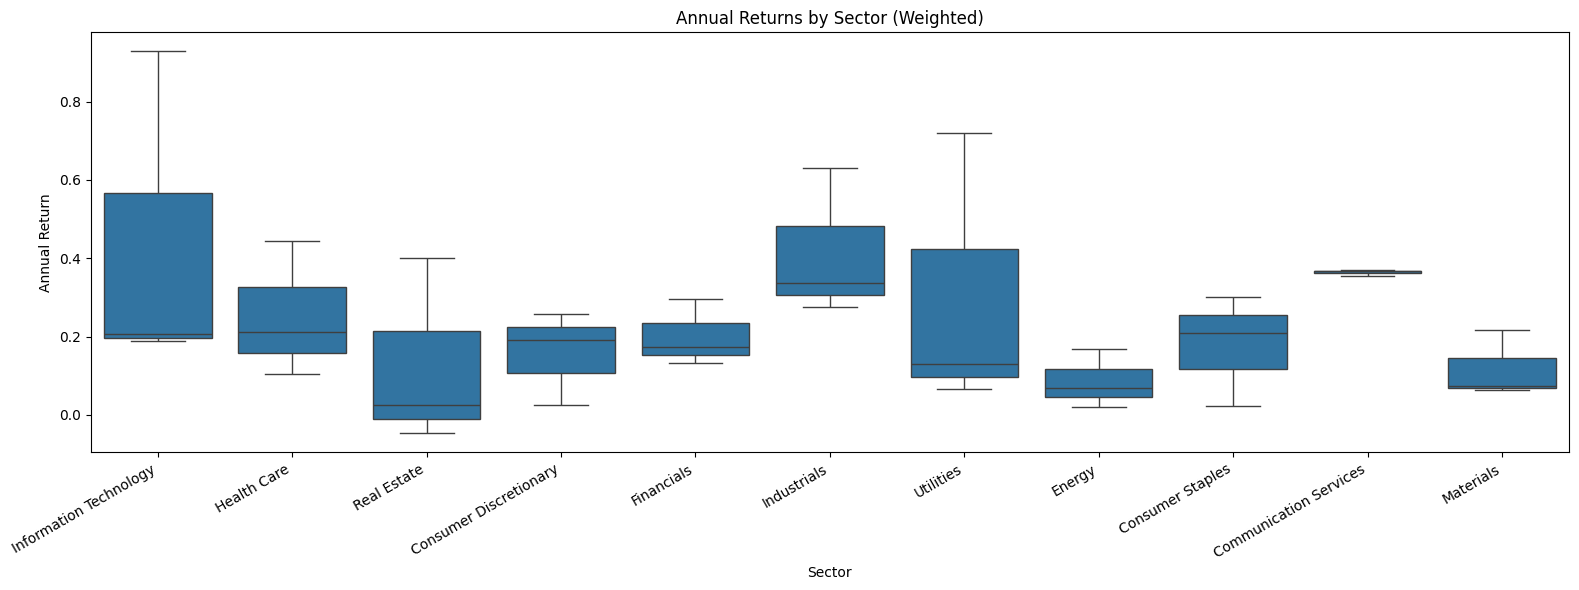

In [32]:
# Boxplot of annual return by sector

import seaborn as sns
import matplotlib.pyplot as plt

# Attach Sector to weighted summary for boxplot
returns_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=returns_df, x="Sector", y="W_Annual_Return")
plt.xticks(rotation=30, ha='right')
plt.title("Annual Returns by Sector (Weighted)")
plt.xlabel("Sector")
plt.ylabel("Annual Return")
plt.tight_layout()
plt.show()

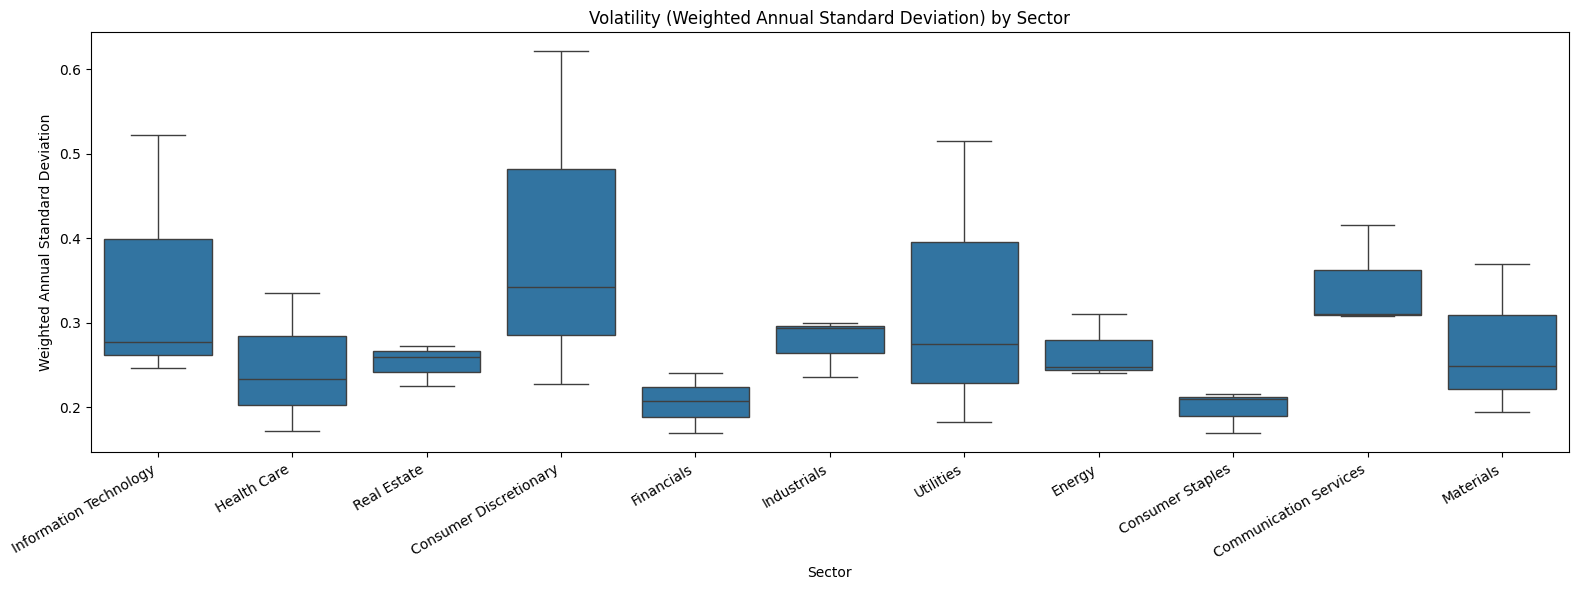

In [33]:
# Boxplot of volatility (SD of returns) by sector

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure Sector column exists in weighted_summary
vol_df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(16, 6))
sns.boxplot(data=vol_df, x="Sector", y="W_Annual_SD")
plt.xticks(rotation=30, ha='right')
plt.title("Volatility (Weighted Annual Standard Deviation) by Sector")
plt.xlabel("Sector")
plt.ylabel("Weighted Annual Standard Deviation")
plt.tight_layout()
plt.show()


Additionally, across the 33 selected stocks, substantial dispersion appears in risk-return characteristics: a small group of companies (NVDA, CEG, GE, and LLY) ranks as the strongest performers, whereas most stocks cluster in the lower-risk, lower-return range as shown in the Stock-level Risk vs Return scatter plot. A few stocks, such as TSLA, exhibit high volatility without commensurate returns.

An industry-level correlation matrix further highlights diversification challenges. Most sectors demonstrate positive correlations with one another. In contrast, only a few, primarily in Energy and Utilities, show near-zero correlations. This confirms the structural difficulty of achieving meaningful diversification within the S&P 500.

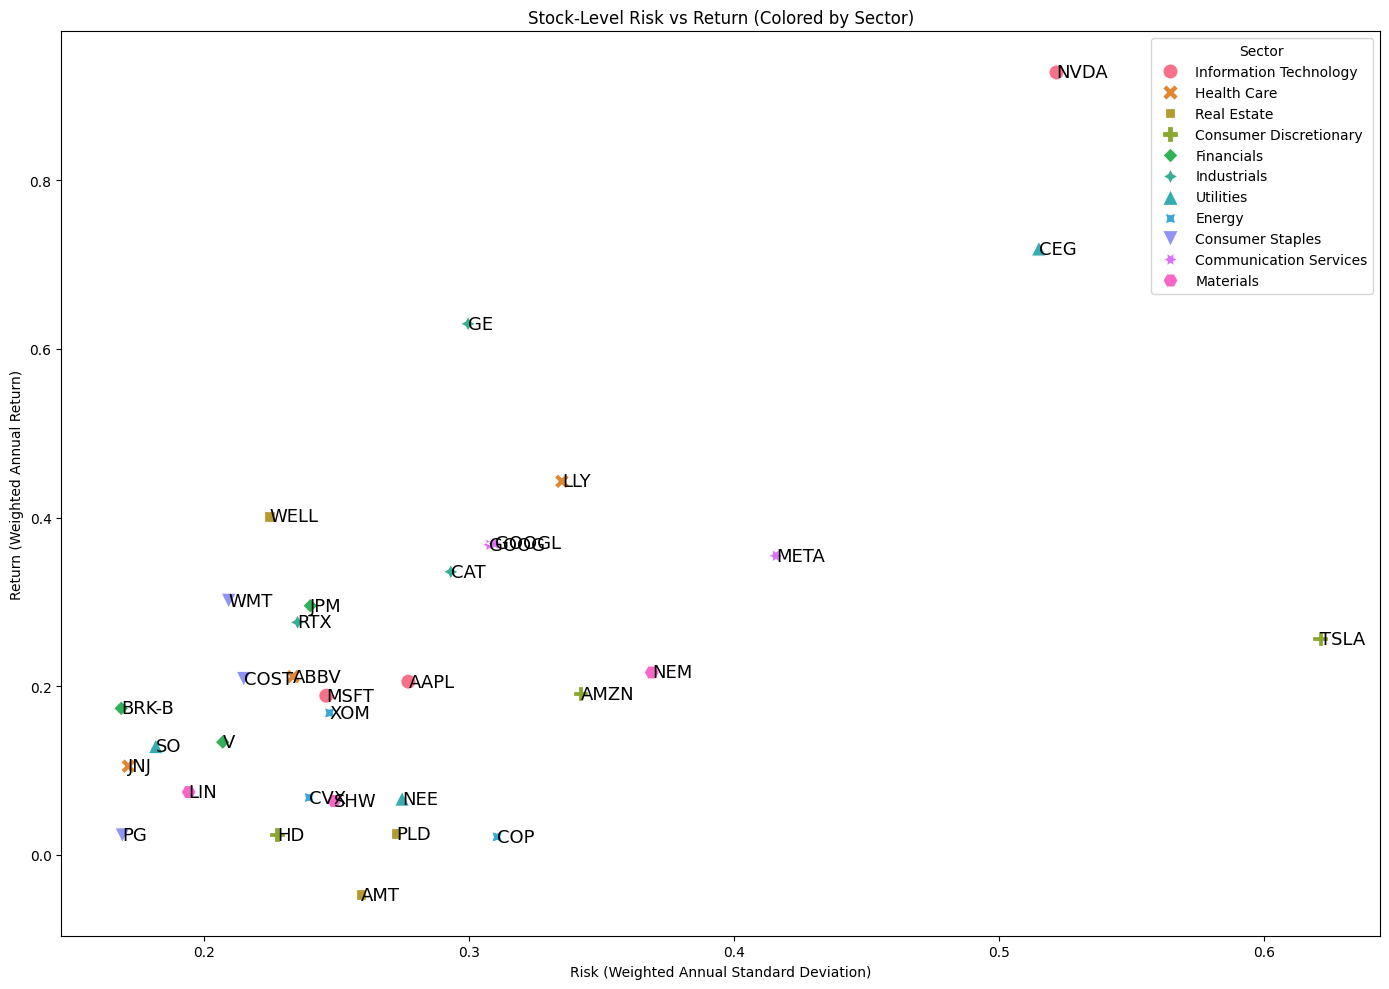

In [34]:
# Risk-Return Map By Stock
import seaborn as sns
import matplotlib.pyplot as plt

# Attach sector for coloring
df = weighted_summary.merge(
    sp500_subset2[["Symbol", "Sector"]].drop_duplicates(),
    on="Symbol",
    how="left"
)

plt.figure(figsize=(14, 10))  # Larger figure size

sns.scatterplot(
    data=df,
    x="W_Annual_SD",
    y="W_Annual_Return",
    hue="Sector",
    style="Sector",
    s=120  # Larger marker size
 )

# Label each point with stock symbol
for _, row in df.iterrows():
    plt.text(
        row["W_Annual_SD"],  # Use correct x axis
        row["W_Annual_Return"],
        row["Symbol"],
        fontsize=13,
        ha='left',
        va='center'
    )

plt.xlabel("Risk (Weighted Annual Standard Deviation)")
plt.ylabel("Return (Weighted Annual Return)")
plt.title("Stock-Level Risk vs Return (Colored by Sector)")
plt.tight_layout()
plt.show()

# Research Questions and Objectives

The main research questions include:
- How can weights be allocated across S&P 500 subset assets to maximize expected returns while managing risk and maintaining diversification?
- How do volatility limits, max weight constraints, and correlation rules affect the optimized portfolio?
- How do results differ across Aggressive, Balanced, and Conservative investor profiles?
- Which constraint(s) have the most substantial impact on return?

To answer these research questions, the project focuses on two core objectives. The first objective is to develop an linear optimization model that maximizes expected returns while satisfying five key constraints related to volatility, correlation, concentration limits, and overall diversification. This model is applied across three investor profiles to generate portfolios containing asset allocation under different risk criteria. A convex optimization framework is used because it provides a reliable way to find a single global optimum and is well suited for portfolio allocation problems.

The second objective is to conduct a sensitivity analysis of the key constraints to assess how the model responds when limits are tightened or relaxed, and to identify plateau points at which additional risk or weight no longer improves returns.

# Model Construction

# Results

## Portfolio Optimization
The portfolio optimization produced three distinct allocations aligned with the investor profiles and their corresponding constraints. The constraint that is contant for all is the max weigth allocation per stock of 75%, allowing the solution to be diversify.

**Aggresive portfolio**

The aggressive portfolio achieves the highest expected return at 78.06%, with a volatility of 36.04%, staying below the 45% limit, and a correlation score of 0.55, which exactly meets the maximum correlation threshold.

Optimal allocation: 

- NVDA – 54.43% (Information Technology)
- CEG – 21.53% (Utilities)
- LLY – 10.87% (Health Care)
- GE – 6.70% (Industrials)
- WELL – 6.47% (Real Estate) 

This allocation favors high-return assets, particularly NVDA, while maintaining exposure across sectors, resulting in moderate diversification.

**Balanced portfolio**

Under tighter risk and correlation constraints, the balanced portfolio delivers a return of 64.17%, with volatility exactly at the 25% risk cap and a correlation score of 0.43, remaining below the 0.45 limit.

Optimal allocation: 
- GE – 29.40% (Industrials)
- NVDA – 26.78% (Information Technology)
- WELL – 17.49% (Real Estate)
- LLY – 17.20% (Health Care)
- CEG – 9.13% (Utilities)

This portfolio selects the same assets as the aggressive profile but distributes weights more evenly. GE and NVDA dominate the allocation while improving diversification relative to the aggressive case.

**Conservative portfolio**

The conservative portfolio yields a return of 49.52%, with volatility set at the 18% maximum risk limit and a correlation score of 0.34, just below the 0.35 cap.

Optimal allocation:
- WELL – 22.87% (Real Estate)
- GE – 18.91% (Industrials)
- WMT – 18.85% (Consumer Staples)
- LLY – 14.54% (Health Care)
- NVDA – 12.91% (Information Technology)
- ABBV – 7.17% (Health Care)
- CEG – 4.75% (Utilities)

This is the most diversified portfolio of the three, adding two new stocks (WMT and ABBV) to improve risk distribution as constraints tighten.

As the constraints tighten, the returns decreases but diversification increases, capturing an interesting trade-off in the optimization solution. We would like to highlight that in the same period the S&P500 mark a return of 85.7%, higher than the aggressive profile. We believe this is due the high correlation in the index. 

| Profile       | Return (%) | Volatility (%) | Vol Limit (%) | CorrScore | Corr Limit | Main Holdings (Ticker: Weight 75% max limit)                                    |
|--------------|------------|----------------|---------------|-----------|------------|--------------------------------------------------------------------|
| Aggressive   | 78.06      | 36.04          | 45            | 0.55      | 0.55       | NVDA 54.43%, CEG 21.53%, LLY 10.87%, GE 6.70%, WELL 6.47%       |
| Balanced     | 64.17      | 25.00          | 25            | 0.43      | 0.45       | GE 29.40%, NVDA 26.78%, WELL 17.49%, LLY 17.20%, CEG 9.13%       |
| Conservative | 49.52      | 18.00          | 18            | 0.34      | 0.35       | WELL 22.87%, GE 18.91%, WMT 18.85%, LLY 14.54%, NVDA 12.91%, ABBV 7.17%, CEG 4.75% |


## Sensitivity Analysis
This analysis further illustrates how each constraint influences the optimization outcome. The baseline settings used for comparison are:

- max volatility: 50%
- max correlation score: 0.55
- max weight per stock: 75%

**Risk sensitivity**

The expected return increases steadily as the volatility limit is relaxed, until plateauing at a max volatility of ~37%, where the portfolio achieves a return of ~78%. Beyond this point, allowing the model to take on additional risk does not improve returns, indicating that the volatility constraint stops binding.

NVDA becomes the dominant asset as soon as the volatility cap exceeds ~33%.Below that threshold, the optimizer spreads weight across GE, LLY, CEG, and WELL to stay within the tighter risk limit.

![Risk Sensitivity](Risk.png)

**Weight sensitivity**

The expected return increases sharply when the maximum allowable weight per stock is loosened, reaching its plateau at ~53.7%, again converging to the same 78% return as the aggressive profile. Increasing the concentration cap beyond this point does not enhance returns.

Tighter weight caps force diversification across five stocks. As soon as the weight limit surpasses ~50%, the optimizer shifts strongly into NVDA while maintaining moderate positions in LLY, CEG, GE, and WELL.

![Weight Sensitivity](Weight.png)

**Correlation sensitivity**

The correlation constraint exhibits the strongest influence on the optimization outcome. Relaxing this constraint significantly increases expected return, with a plateau reached at a correlation score of ~0.811, enabling the model to achieve its highest return of 88%.

Across all three sensibility analysis (risk, maximum weight, and correlation) the optimal solution consistently assigns the largest allocation to NVDA whenever the constraints permit it, while GE, LLY, CEG, and WELL serve as secondary positions that enter the portfolio as tighter limits require greater diversification.

![Correlation Sensitivity](Corr.png)

# Conclusion

This project highlights the importance of understanding how investor behavior and portfolio constraints shape the construction of an optimal portfolio. Despite applying different limitations across the aggressive, balanced, and conservative profiles, the optimal solution consistently selects a similar group of high-return stocks—most notably NVDA, CEG, and LLY—indicating that these assets dominate the risk–return landscape of the selected dataset.

As constraints tighten, expected returns decrease from 78% (aggressive) to 64% (balanced) and 49.5% (conservative), but diversification increased, illustrating the fundamental trade-off between return and diversification. Over the same period, the S&P 500 delivered an 85.7% return across more than 500 companies, demonstrating how not only broader diversification but also higher correlation across the index influence overall performance.

The sensitivity analysis further shows that risk and weight constraints produce diminishing marginal benefits after certain thresholds, with return plateaus occurring at 37.1% volatility and 57.4% maximum weight, both converging near 78% expected return. In contrast, the correlation constraint has the strongest impact: relaxing the correlation cap from 0.55 to 0.811 increases expected return to 88%, showing that diversification requirements materially restrict the optimizer’s ability to concentrate in top-performing assets.

Across all constraint analyses, NVDA remains the leading allocation whenever allowed, while GE, LLY, CEG, and WELL contribute to diversification when stricter limits reduce concentration. Overall, the model demonstrates that while mathematical optimization can identify high-return portfolios, thoughtful constraint design is essential to ensure financially robust and diversified outcomes.

### **1. Daily Simple Return**

$$
R_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}
$$

### **2. Daily Log Return**

$$
\text{LogReturn}_{i,t} = \ln(1 + R_{i,t})
$$



### **3. Weighted Mean**
$$
\bar{v}_w = \frac{\sum_{t} w_t v_t}{\sum_{t} w_t}
$$

### **4. Weighted Standard Deviation**

$$
\sigma_w = 
\sqrt{
\frac{\sum_{t} w_t (v_t - \bar{v}_w)^2}{\sum_{t} w_t}
}
$$



### **5. Annualized Log Return**

$$
\text{AnnualLogReturn}_i = 252 \cdot \bar{r}_{i,\text{log},w}
$$

### **6. Annualized Simple Return (from log return)**

$$
\text{AnnualReturn}_i = e^{\text{AnnualLogReturn}_i} - 1
$$

### **7. Annualized Standard Deviation**

$$
\text{AnnualSD}_i = \sigma_{i,w} \sqrt{252}
$$

```python


# Appendix

In [24]:
import json
from IPython.display import Markdown, Code

with open('Report.ipynb', 'r') as f:
    nb = json.load(f)

print("=" * 70)
print("APPENDIX: COMPLETE SOURCE CODE")
print("=" * 70)

# Extract all code cells (skip markdown)
for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        code = ''.join(cell['source'])
        if code.strip():  # Only show non-empty cells
            print(f"\n--- Code Cell {i} ---\n")
            print(code)
            print()

APPENDIX: COMPLETE SOURCE CODE

--- Code Cell 2 ---

import pandas as pd
import numpy as np

# Load data

sectors_wgts = pd.read_csv("../data/sp500_wgts_sectors.csv")
sp500_subset = pd.read_csv("../data/sp500_subset.csv")

# Clean symbols
sectors_wgts["Symbol"] = sectors_wgts["Symbol"].astype(str).str.strip()
sp500_subset["Symbol"] = sp500_subset["Symbol"].astype(str).str.strip()

# Ensure Date is datetime
sp500_subset["Date"] = pd.to_datetime(sp500_subset["Date"])



--- Code Cell 3 ---

# Merge weights into price data

sp500_subset = sp500_subset.merge(
    sectors_wgts[["Symbol", "Weight"]],
    on="Symbol",
    how="left",
    validate="many_to_one"   # ensures weights only appear once per symbol
)



--- Code Cell 6 ---

sp500_subset.head()


--- Code Cell 7 ---

# Quick checks

# S&P 500 Subset (Price Data)

print("Price data shape:", sp500_subset.shape)
print("\nColumns in price data:", sp500_subset.columns)
print("\nDate range:")
print("Min:", sp500_subset["Date"].min(), "| Max